In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates



import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

from scipy.stats import linregress
from scipy.stats import norm

import statistics as st

import functools as ft

In [2]:
path_name = '../data/uahncdc_lt_6.1.csv'

uah = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=".",
    dtype={"Year": "int64", "Mo": "int64"}
)

uah["Date"] = pd.to_datetime(dict(year=uah["Year"], month=uah["Mo"], day=1))
uah["Diff"] = uah["Globe"].diff()

Text(0, 0.5, 'Anomaly from 1991-2020  $C\\degree$')

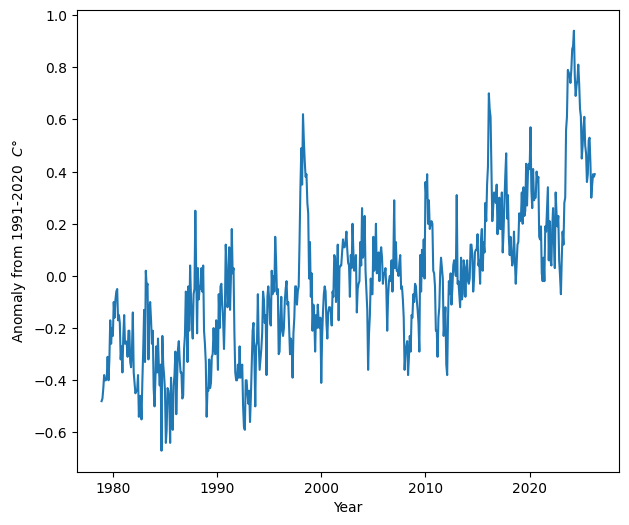

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))



ax.plot(uah["Date"], uah["Globe"])

ax.set_xlabel("Year")
ax.set_ylabel(r"Anomaly from 1991-2020  $C\degree$")

Slope      = 0.016
Intercept  = -31.334
r          = 0.741
R²         = 0.548
p-value    = 5.667e-100


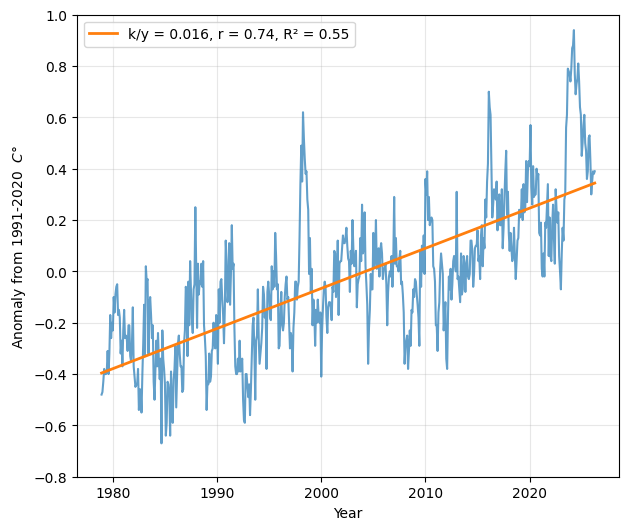

In [4]:


x = uah["Year"] + (uah["Mo"] - 1)/12
y = uah["Globe"]

res = linregress(x,y)

print(f"Slope      = {res.slope:.3f}")
print(f"Intercept  = {res.intercept:.3f}")
print(f"r          = {res.rvalue:.3f}")
print(f"R²         = {res.rvalue**2:.3f}")
print(f"p-value    = {res.pvalue:.3e}")

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter points
ax.plot(x, uah["Globe"], alpha=0.7)

# Regression line
xx = np.linspace(x.min(), x.max(), 100)
yy = res.intercept + res.slope * xx

ax.plot(
    xx,
    yy,
    linewidth=2,
    label=f"k/y = {res.slope:.3f}, r = {res.rvalue:.2f}, R² = {res.rvalue**2:.2f}"
)

ax.set_ylabel(r"Anomaly from 1991-2020  $C\degree$")
ax.set_xlabel("Year")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(-0.8, 1)
plt.savefig("img/uah-temp1.pdf")

plt.show()

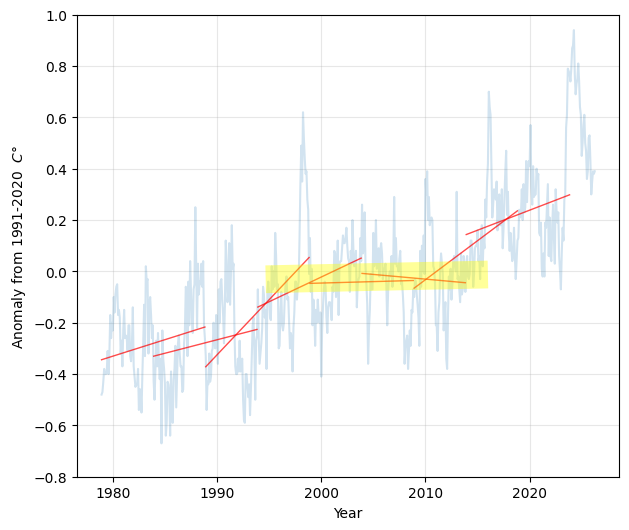

In [5]:
x = uah["Year"] + (uah["Mo"] - 1)/12
y = uah["Globe"]

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter points
ax.plot(x, uah["Globe"], alpha=0.2)


s = 0
k = 60
n = 120

while s < (len(x) - n): 
    xs = x[s:s+n]
    ys = y[s:s+n]
    res = linregress(xs,ys)
    # Regression line
    xx = np.linspace(xs.min(), xs.max(), n)
    yy = res.intercept + res.slope * xx
    s = s + k
    ax.plot(
       xx,
       yy,
       alpha=0.7,
       linewidth=1,
       color='red'
)


s = 205
n = 225

xs = x[s:s+n]
ys = y[s:s+n]
res = linregress(xs,ys)
# Regression line
xx = np.linspace(xs.min(), xs.max(), n)
yy = res.intercept + res.slope * xx

ax.plot(
    xx,
    yy,
    linewidth=20,
    alpha=0.4,
    color='yellow'
)
ax.set_ylabel(r"Anomaly from 1991-2020  $C\degree$")
ax.set_xlabel("Year")
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.8, 1)

plt.savefig("img/uah-temp2.pdf")

plt.show()

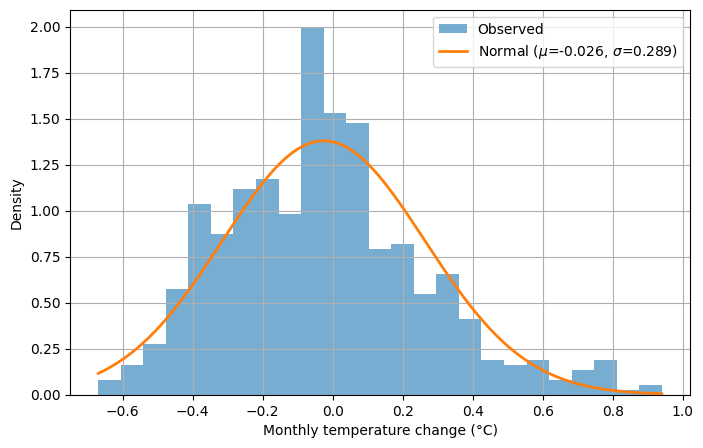

In [6]:

x = uah["Globe"].dropna()

mu = x.mean()
sigma = x.std()

plt.figure(figsize=(8,5))
plt.hist(x, bins=25, density=True, alpha=0.6,
         label="Observed")

# Matching normal distribution
xx = np.linspace(x.min(), x.max(), 500)
plt.plot(xx, norm.pdf(xx, mu, sigma),
         linewidth=2,
         label=f"Normal ($\\mu$={mu:.3f}, $\\sigma$={sigma:.3f})")

plt.xlabel("Monthly temperature change (°C)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.savefig("img/uah-hist.pdf")
plt.show()

<Figure size 1000x500 with 0 Axes>

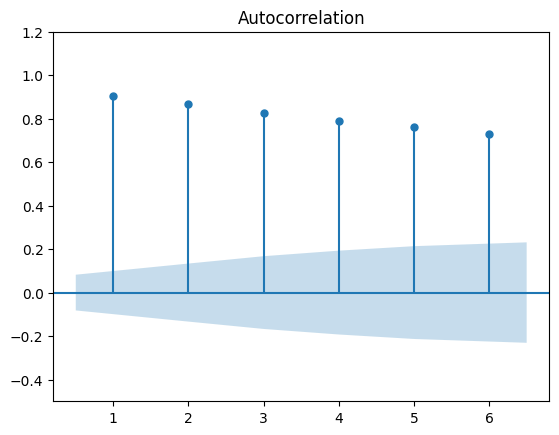

In [7]:
y = uah["Globe"]

plt.figure(figsize=(10,5))
plot_acf(y, lags=[1,2,3,4,5,6], zero=False)
plt.ylim(-0.5,1.2)
plt.show()

In [8]:
rho1 = y.autocorr(lag=1)
print(rho1)

0.9098513633559218


Slope      = -0.000
Intercept  = 0.019
r          = -0.001
R²         = 0.000
p-value    = 9.820e-01


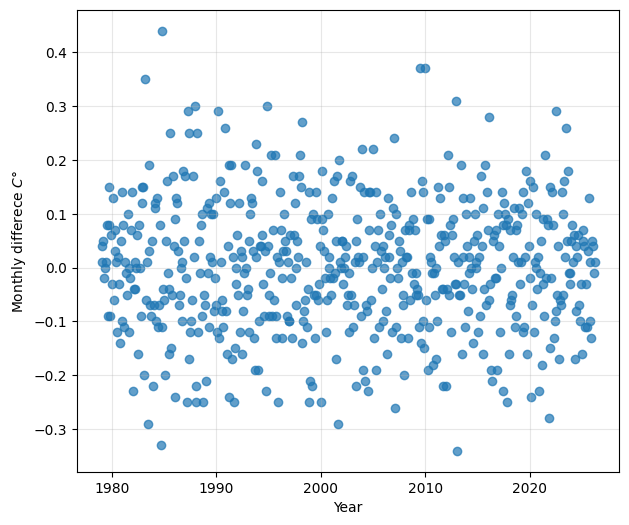

In [9]:


x = (uah["Year"] + (uah["Mo"] - 1)/12)[1:]
y = uah["Diff"][1:]

res = linregress(x,y)

print(f"Slope      = {res.slope:.3f}")
print(f"Intercept  = {res.intercept:.3f}")
print(f"r          = {res.rvalue:.3f}")
print(f"R²         = {res.rvalue**2:.3f}")
print(f"p-value    = {res.pvalue:.3e}")

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter points
ax.scatter(x, uah["Diff"][1:], alpha=0.7)



ax.set_ylabel(r"Monthly differece $C\degree$")
ax.set_xlabel("Year")
ax.grid(True, alpha=0.3)


plt.savefig("img/uah-diff.pdf")

plt.show()

-0.307839055512904


<Figure size 1000x500 with 0 Axes>

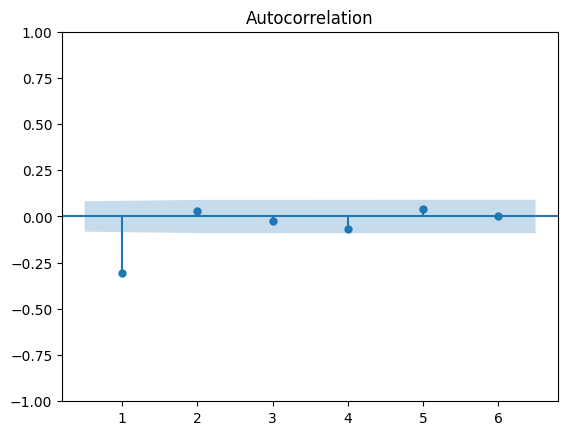

In [10]:
y = uah["Diff"][1:]

plt.figure(figsize=(10,5))
plot_acf(y, lags=[1,2,3,4,5,6], zero=False)

print(y.autocorr(lag=1))

plt.show()

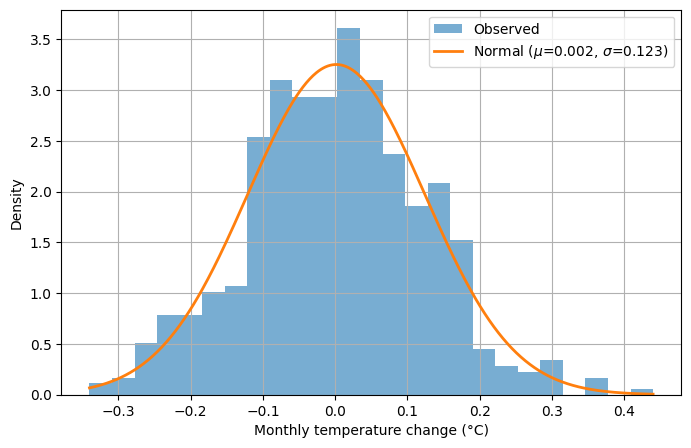

In [11]:


x = uah["Diff"].dropna()

mu = x.mean()
sigma = x.std()

plt.figure(figsize=(8,5))
plt.hist(x, bins=25, density=True, alpha=0.6,
         label="Observed")

# Matching normal distribution
xx = np.linspace(x.min(), x.max(), 500)
plt.plot(xx, norm.pdf(xx, mu, sigma),
         linewidth=2,
         label=f"Normal ($\\mu$={mu:.3f}, $\\sigma$={sigma:.3f})")

plt.xlabel("Monthly temperature change (°C)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.savefig("img/uah-hist.pdf")
plt.show()

In [12]:
len(uah["Diff"])


569

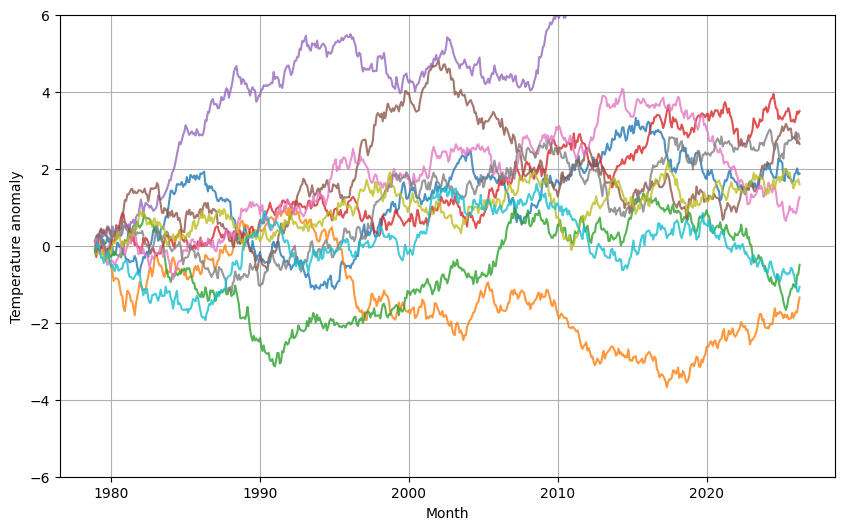

In [13]:
from scipy.stats import norm


nsteps = 569
nwalks = 10

sigma = uah["Diff"][1:].std()

# Random monthly changes
increments = np.random.normal(
    loc=0.0,
    scale=sigma,
    size=(nwalks, nsteps)
)

# Random walks
walks = np.cumsum(increments, axis=1)

plt.figure(figsize=(10,6))

for i in range(nwalks):
    plt.plot(uah["Date"],walks[i], alpha=0.8)

plt.xlabel("Month")
plt.ylabel("Temperature anomaly")

plt.ylim(-6,6)
plt.grid(True)
#plt.savefig("img/random-walk.pdf")
plt.show()

In [14]:
temp = uah["Globe"].shift(1)[1:]
diff = uah["Diff"][1:]



slope, intercept, r, p, stderr = linregress(temp, diff)

print(f"slope = {slope:.3f}")
print(f"inter = {intercept:.3f}")
print(f"r     = {r:.3f}")
print(f"p     = {p:.3e}")



slope = -0.090
inter = -0.001
r     = -0.213
p     = 2.952e-07


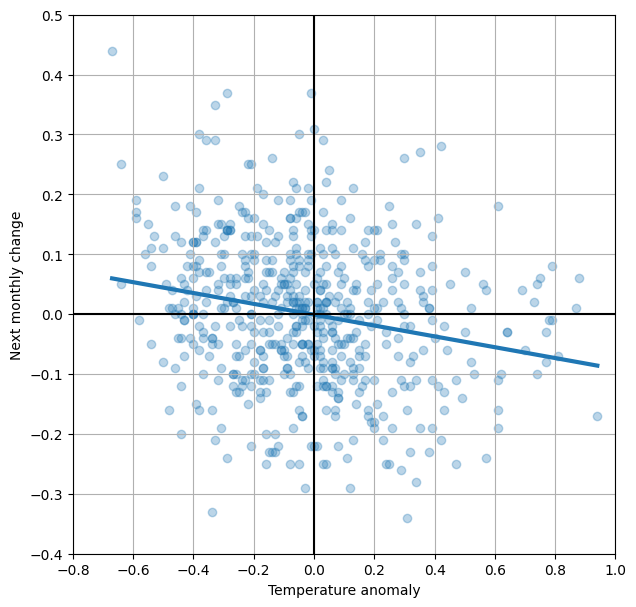

In [15]:
temp = uah["Globe"].shift(1)[1:]
diff = uah["Diff"][1:]



slope, intercept, r, p, stderr = linregress(temp, diff)




x = np.linspace(temp.min(), temp.max(), 100)

plt.figure(figsize=(7,7))

plt.scatter(temp, diff, alpha=0.3)
plt.plot(x, intercept + slope*x, linewidth=3)

plt.axhline(0, color="black")
plt.axvline(0, color="black")

plt.ylim(-0.4,0.5)
plt.xlim(-0.8, 1.0)

plt.xlabel("Temperature anomaly")
plt.ylabel("Next monthly change")

plt.grid(True)
plt.savefig("img/diff-cor.pdf")
plt.show()

In [16]:
nsteps = len(uah)
nwalks = 4

res = linregress(temp, diff)

residual = diff - (res.slope*temp + res.intercept)

sigma = residual.std()

print(f"slope = {res.slope:.3f}")

print(f"mean = {residual.mean():.3f}")
print(f"sigma = {sigma:.3f}")

walks = np.zeros((nwalks, nsteps))

for w in range(nwalks):

    walks[w,0] = 0
    #walks[w,0] = uah["Globe"].iloc[0]

    for t in range(1, nsteps):

        eps = np.random.normal(0, sigma)

        walks[w,t] = (
            walks[w,t-1]
            + res.slope*walks[w,t-1]
            + eps
        )

slope = -0.090
mean = -0.000
sigma = 0.120


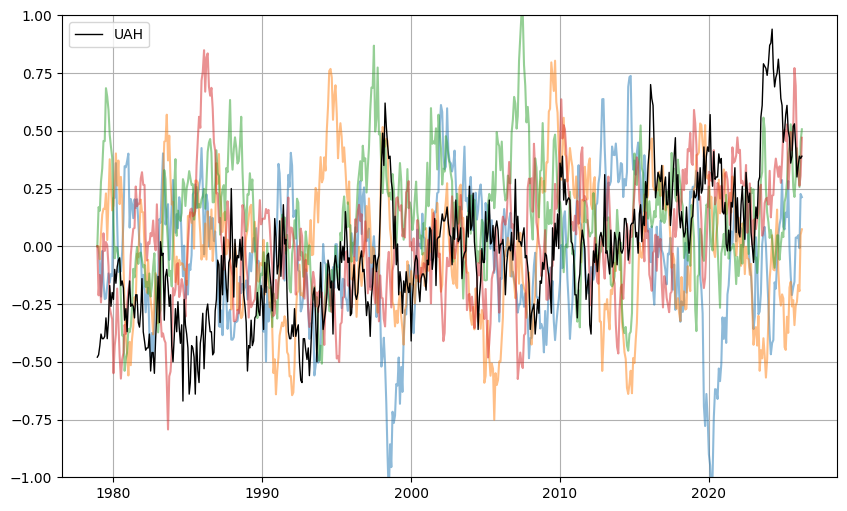

In [17]:
fig, ax = plt.subplots(figsize=(10,6))

for w in range(nwalks):
    ax.plot(
        uah["Date"],
        walks[w],
        alpha=0.5
    )

ax.plot(    uah["Date"],   uah["Globe"],   color="black",   linewidth=1,   label="UAH" )

ax.set_ylim(-1,1)
ax.legend()
ax.grid(True)




#plt.savefig("img/model.pdf")
plt.show()

In [18]:
nsteps = len(uah)
nwalks = 20

res = linregress(temp, diff)

residual = diff - (res.slope*temp + res.intercept)

sigma = residual.std()

print(f"slope = {res.slope:.3f}")

print(f"mean = {residual.mean():.3f}")
print(f"sigma = {sigma:.3f}")

walks = np.zeros((nwalks, nsteps))

for w in range(nwalks):

    walks[w,0] = 0
    #walks[w,0] = uah["Globe"].iloc[0]

    for t in range(1, nsteps):

        eps = np.random.normal(0, sigma)

        walks[w,t] = (
            walks[w,t-1]
            + res.slope*walks[w,t-1]
            + eps
        )

slope = -0.090
mean = -0.000
sigma = 0.120


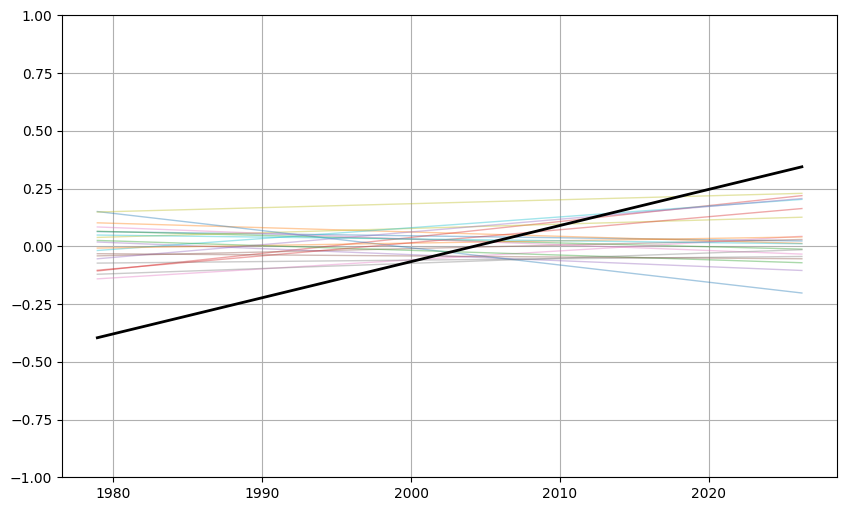

In [19]:
fig, ax = plt.subplots(figsize=(10,6))

x = uah["Year"] + (uah["Mo"] - 1)/12
xx = np.linspace(x.min(), x.max(), 100)

for w in range(nwalks):

    res = linregress(x, walks[w])  

    yy = res.intercept + res.slope * xx
    ax.plot(
      xx,
      yy,
      linewidth=1,
        alpha=0.4
    )

res = linregress(x, uah["Globe"])
yy = res.intercept + res.slope * xx

ax.plot(
    xx,
    yy,
    color="black",
    linewidth=2
)
ax.grid(True)
ax.set_ylim(-1,1)

plt.savefig("img/model-trend.pdf")
plt.show()

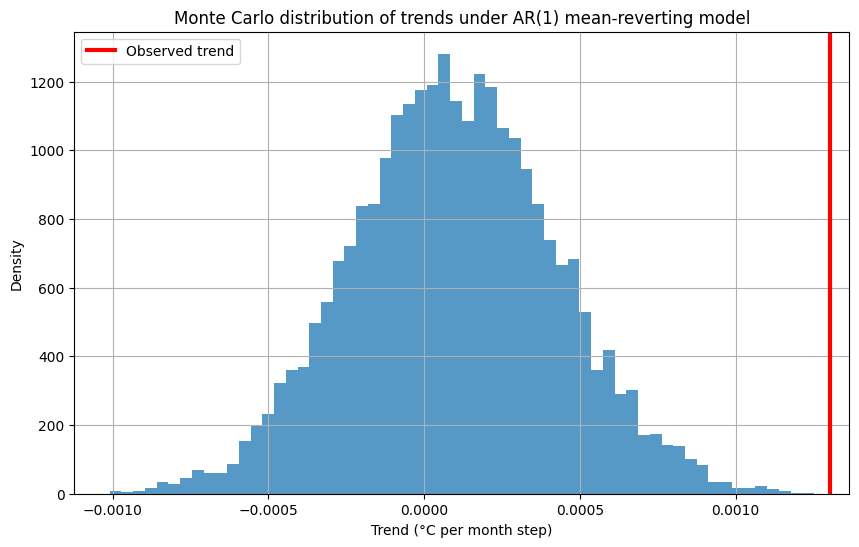

Observed slope: 0.0013028247181730655
MC mean slope: 9.427899967912645e-05
MC std slope: 0.0003278243758381279
Percentile of observed: 1.0


In [20]:
# ----------------------------
# Parameters from your data
# ----------------------------
phi = 0.91
nsteps = 569
nsims = 10000

# estimate noise from data (recommended choice)
sigma_eps = residual.std()   # from your earlier regression step

# time axis for trend fitting
t = np.arange(nsteps)

# store trends
slopes = np.zeros(nsims)

# ----------------------------
# Monte Carlo simulation
# ----------------------------
for i in range(nsims):

    x = np.zeros(nsteps)

    # initial condition
    x[0] = uah["Globe"].iloc[0]

    # generate AR(1)
    for t_idx in range(1, nsteps):
        eps = np.random.normal(0, sigma_eps)
        x[t_idx] = phi * x[t_idx - 1] + eps

    # compute linear trend
    slope, _, _, _, _ = linregress(np.arange(nsteps), x)
    slopes[i] = slope


# ----------------------------
# Plot histogram
# ----------------------------
plt.figure(figsize=(10,6))
plt.hist(slopes, bins=60, density=True, alpha=0.75)

# observed trend
obs = linregress(
    np.arange(len(uah["Globe"])),
    uah["Globe"].values
)

plt.axvline(obs.slope, color="red", linewidth=3, label="Observed trend")

plt.xlabel("Trend (°C per month step)")
plt.ylabel("Density")
plt.title("Monte Carlo distribution of trends under AR(1) mean-reverting model")
plt.legend()
plt.grid(True)
plt.show()

print("Observed slope:", obs.slope)
print("MC mean slope:", slopes.mean())
print("MC std slope:", slopes.std())
print("Percentile of observed:", np.mean(slopes < obs.slope))

In [21]:
uah["Globe"].iloc[0]

np.float64(-0.48)

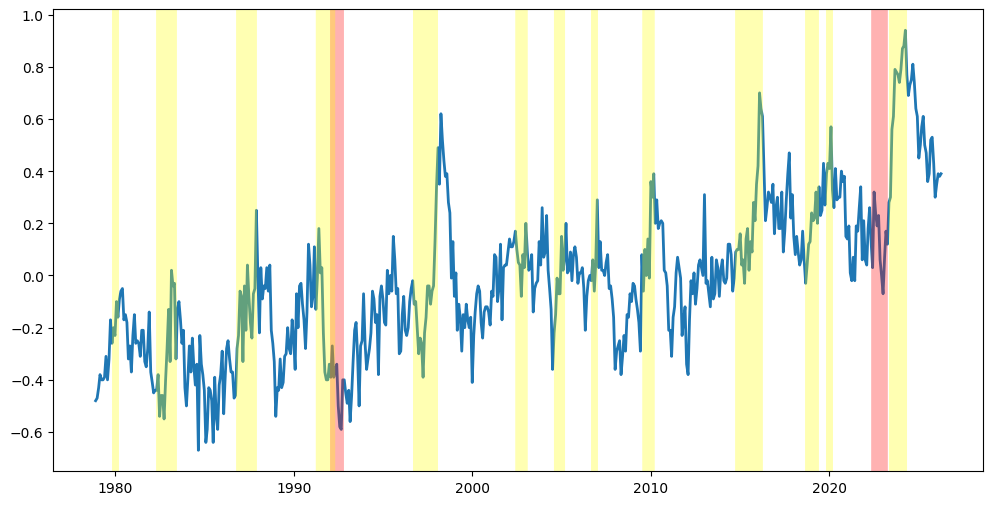

In [22]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(uah["Date"], uah["Globe"], lw=2)




volcano = [ ("1992-06", 10), ("2022-10", 12)]

for (x,w) in volcano :
    plt.axvline(pd.Timestamp(x), color="red", alpha=0.3, linewidth=w)


oni = [("1980-01",5), ("1982-11", 15), ("1987-05", 15), ("1991-10", 14),("1997-05", 18), ("2002-10", 9), ("2004-11", 8), ("2006-11", 5), ("2009-11", 9), ("2015-07", 20), ("2019-01", 10), ("2020-01", 5), ("2023-11", 13)]

for (x,w) in oni :
    plt.axvline(pd.Timestamp(x), color="yellow", alpha=0.3, linewidth=w)

plt.savefig("img/enso.pdf")

In [54]:
u = uah.set_index("Date")

# 6-month means
g6 = u["Globe"].resample("6MS").mean()

In [55]:
print(g6.head())
print(len(g6))

Date
1978-12-01   -0.426667
1979-06-01   -0.308333
1979-12-01   -0.140000
1980-06-01   -0.190000
1980-12-01   -0.253333
Freq: 6MS, Name: Globe, dtype: float64
95


In [56]:
d6 = g6.diff().dropna()

In [57]:
temp = g6.shift(1).dropna()
diff = d6

# align indices
temp = temp.loc[diff.index]

slope, intercept, r, p, stderr = linregress(temp, diff)

print("slope =", slope)
print("correlation =", r)

slope = -0.17134762109945267
correlation = -0.29339426086407616


In [58]:
alpha = -slope

eps = diff + alpha * temp

print("lag-1 autocorr of residuals:",
      eps.autocorr(lag=1))

sigma_eps = eps.std()

lag-1 autocorr of residuals: 0.08058713204771978


In [59]:
phi = 1 + slope

In [60]:


nsims = 10000
nsteps = len(g6)

trends = np.zeros(nsims)
finals = np.zeros(nsims)

for i in range(nsims):

    x = np.zeros(nsteps)

    x[0] = g6.iloc[0]

    for t in range(1, nsteps):

        eps_t = np.random.normal(0, sigma_eps)

        x[t] = phi * x[t-1] + eps_t

    slope_i, *_ = linregress(
        np.arange(nsteps),
        x
    )

    trends[i] = slope_i
    finals[i] = x[-1]

In [61]:
obs_slope, *_ = linregress(
    np.arange(len(g6)),
    g6.values
)

print("Observed slope:", obs_slope)

print(
    "Percentile:",
    np.mean(trends < obs_slope)
)

Observed slope: 0.00781773516237402
Percentile: 0.9837


In [62]:
print("Monthly:")
print(uah["Globe"].autocorr(1))

print("Six-month:")
print(g6.autocorr(1))

Monthly:
0.9098513633559218
Six-month:
0.8293235122142224


In [63]:
trends.mean()

np.float64(0.0015064206971821985)

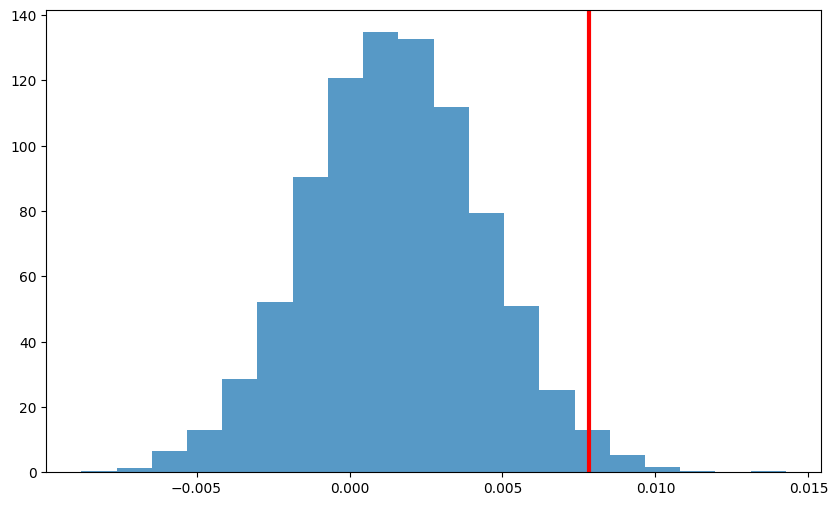

In [64]:
plt.figure(figsize=(10,6))
plt.hist(trends, bins=20, density=True, alpha=0.75)
plt.axvline(obs_slope, color="red", linewidth=3, label="Observed trend")


In [65]:
print("trends std: ", trends.std())
print(" obs slope: ", obs_slope)
print(" ratio: ", obs_slope/trends.std())

trends std:  0.0028946551460121784
 obs slope:  0.00781773516237402
 ratio:  2.700748368296694


finalss std:  0.2751896408341326
 obs final:  0.362


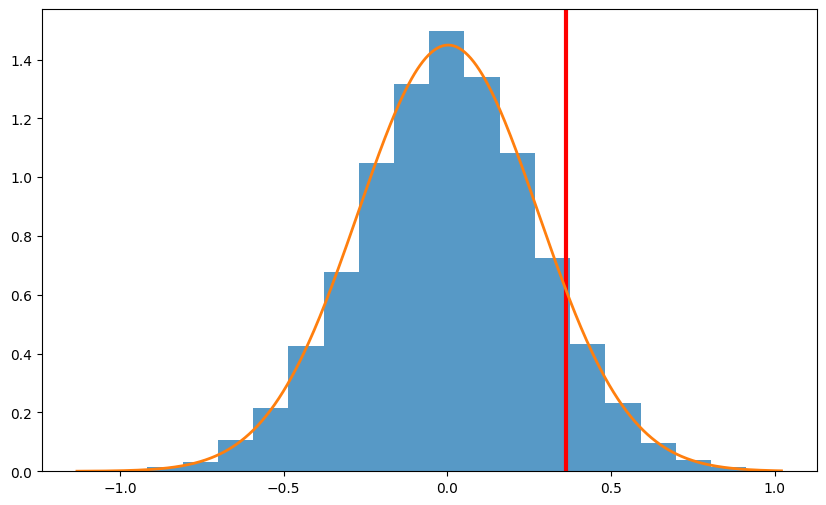

In [66]:
plt.figure(figsize=(10,6))
plt.hist(finals, bins=20, density=True, alpha=0.75)
plt.axvline(g6.values[-1], color="red", linewidth=3, label="Observed trend")

mu = finals.mean()
sigma = finals.std()

xx = np.linspace(finals.min(), finals.max(), 500)
plt.plot(xx, norm.pdf(xx, mu, sigma),
         linewidth=2,
         label=f"Normal ($\\mu$={mu:.3f}, $\\sigma$={sigma:.3f})")



print("finalss std: ", finals.std())
print(" obs final: ", g6.values[-1])

In [67]:
g6.values[-1]

np.float64(0.362)

0.08058713204771978


<Figure size 1000x500 with 0 Axes>

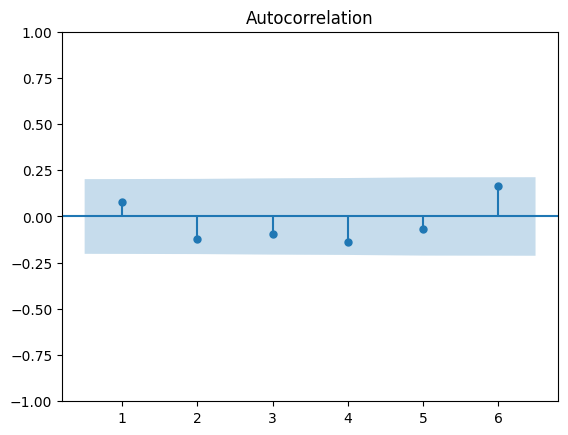

In [68]:
plt.figure(figsize=(10,5))
plot_acf(eps, lags=[1,2,3,4,5,6], zero=False)

print(eps.autocorr(lag=1))

plt.show()